In [11]:
import random
from collections import deque, namedtuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import requests
import apimoex

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cpu


In [27]:

# ==========================================
# 1. СОЗДАНИЕ СРЕДЫ (РЫНКА) 
# ==========================================

class PortfolioEnv:
    """
    Торговая среда с портфелем из одного актива.

    Состояние:
        [окно нормализованных цен (window),
         cash / initial_cash,            # ликвидная часть
         shares * price / equity,        # доля акций в портфеле
         equity / initial_cash]          # относительный капитал

    Действия (дискретные):
        0 = удерживать
        1 = купить 25% доступных денег
        2 = купить 50% доступных денег
        3 = купить 100% доступных денег
        4 = продать 25% позиции
        5 = продать 50% позиции
        6 = продать 100% позиции

    Награда: изменение equity относительно предыдущего шага,
             нормированное на price_std.
    """



    def __init__(self, prices, window=5, initial_cash=10_000.0,
                 commission=0.001, hold_penalty=0.0):
        self.prices = prices.astype(np.float32)
        self.window = window
        self.initial_cash = float(initial_cash)
        self.commission = commission
        self.hold_penalty = hold_penalty

        self.price_mean = float(self.prices.mean())
        self.price_std = float(self.prices.std() + 1e-8)
        self.n_actions = 7
        self.total_profit = 0.0 

        self.reset()

    # ---------- состояние ----------
    def _state(self):
        t = self.current_step
        lo = max(0, t - self.window + 1)
        window_prices = self.prices[lo:t + 1]
        if len(window_prices) < self.window:
            pad = np.full(self.window - len(window_prices), window_prices[0])
            window_prices = np.concatenate([pad, window_prices])
        norm_window = (window_prices - self.price_mean) / self.price_std

        price = float(self.prices[t])
        equity = self.cash + self.shares * price
        cash_frac = self.cash / self.initial_cash
        stock_frac = (self.shares * price) / max(equity, 1e-8)
        equity_frac = equity / self.initial_cash

        return np.concatenate([
            norm_window,
            [cash_frac, stock_frac, equity_frac],
        ]).astype(np.float32)

    @property
    def state_dim(self):
        return self.window + 3

    # ---------- сброс ----------
    def reset(self):
        self.current_step = 0
        self.cash = self.initial_cash
        self.shares = 0.0
        self.equity_curve = [self.initial_cash]
        self.trade_count = 0
        self.total_profit = 0.0 
        return self._state()

    # ---------- исполнение сделок ----------
    def _buy(self, fraction):
        price = float(self.prices[self.current_step])
        # сколько акций можем купить с учётом комиссии
        budget = self.cash * fraction
        if budget <= 0:
            return
        cost_per_share = price * (1 + self.commission)
        n_shares = budget / cost_per_share
        self.shares += n_shares
        self.cash -= n_shares * cost_per_share
        self.trade_count += 1

    def _sell(self, fraction):
        price = float(self.prices[self.current_step])
        if self.shares <= 0:
            return
        n_shares = self.shares * fraction
        revenue = n_shares * price * (1 - self.commission)
        self.shares -= n_shares
        self.cash += revenue
        self.trade_count += 1

    # ---------- шаг ----------
    def step(self, action):
        price = float(self.prices[self.current_step])
        equity_before = self.cash + self.shares * price

        if action == 1: self._buy(0.25)
        elif action == 2: self._buy(0.50)
        elif action == 3: self._buy(1.00)
        elif action == 4: self._sell(0.25)
        elif action == 5: self._sell(0.50)
        elif action == 6: self._sell(1.00)

        # переход на следующий шаг
        self.current_step += 1
        done = self.current_step >= len(self.prices) - 1

        next_price = float(self.prices[self.current_step])
        equity_after = self.cash + self.shares * next_price

        # награда = изменение капитала, нормированное
        reward = (equity_after - equity_before) / self.price_std
        reward -= self.hold_penalty

        self.equity_curve.append(equity_after)
        self.total_profit = equity_after - self.initial_cash
        return self._state(), reward, done

In [ ]:
# ==========================================
# 2. НЕЙРОСЕТЬ АГЕНТА (DeepQ-Network)
# ==========================================
class DQN(nn.Module):
    def __init__(self, state_dim, n_actions=3, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))


class ReplayBuffer:
    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)


class DQNAgent:
    def __init__(self, state_dim, n_actions=3, lr=1e-3,
                 gamma=0.97, buffer_size=10_000, batch_size=64,
                 target_update=200):
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update = target_update

        self.policy_net = DQN(state_dim, n_actions).to(device)
        self.target_net = DQN(state_dim, n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()
        self.buffer = ReplayBuffer(buffer_size)
        self.steps = 0

    def select_action(self, state, epsilon):
        if random.random() < epsilon:
            return random.randrange(self.n_actions)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q = self.policy_net(s)
            return int(q.argmax(dim=1).item())

    def push(self, *args):
        self.buffer.push(*args)

    def update(self):
        if len(self.buffer) < self.batch_size:
            return None

        batch = self.buffer.sample(self.batch_size)
        states      = torch.tensor(np.array(batch.state),      dtype=torch.float32, device=device)
        actions     = torch.tensor(batch.action,               dtype=torch.long,    device=device).unsqueeze(1)
        rewards     = torch.tensor(batch.reward,               dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
        dones       = torch.tensor(batch.done,                 dtype=torch.float32, device=device).unsqueeze(1)

        # Для каждого элемента батча берется ровно одно Q-значение — 
        # то, которое соответствует фактически выполненному действию.
        q_values = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            next_q = self.target_net(next_states).max(dim=1, keepdim=True)[0]
            target = rewards + self.gamma * next_q * (1.0 - dones)

        loss = self.loss_fn(q_values, target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 5.0)
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()


In [39]:

# ==========================================
# 3. ЦИКЛ ОБУЧЕНИЯ (Reinforcement Learning)
# ==========================================
def epsilon_by_episode(ep, n_episodes, eps_start=1.0, eps_end=0.05, decay=0.995):
    return max(eps_end, eps_start * (decay ** ep))


def train(env, agent=None, n_episodes=600, eps_start=1.0, eps_end=0.05,
          decay=0.995, verbose_every=50, log_equity=True):
    """
    Обучение DQN-агента в среде PortfolioEnv.

    Параметры
    ---------
    env : PortfolioEnv
        Среда. Должна иметь атрибуты state_dim, n_actions, trade_count,
        total_profit, equity_curve, initial_cash.
    n_episodes : int
        Число эпизодов обучения.
    eps_start, eps_end : float
        Начальное и конечное значение epsilon для epsilon-greedy.
    decay : float
        Коэффициент экспоненциального затухания epsilon за эпизод.
    verbose_every : int
        Печатать лог каждые verbose_every эпизодов.
    log_equity : bool
        Если True — печатать финальный equity и profit эпизода.

    Возвращает
    ----------
    agent : DQNAgent
    history : dict с ключами 'reward', 'loss', 'eps', 'equity', 'profit', 'trades'
    """
    if agent is None:
        # Агент создаётся внутри функции под размерности конкретной среды
        agent = DQNAgent(
            state_dim=env.state_dim,
            n_actions=env.n_actions,
        )

    history = {
        'reward': [],
        'loss':   [],
        'eps':    [],
        'equity': [],
        'profit': [],
        'trades': [],
    }

    for ep in range(n_episodes):
        state = env.reset()
        done = False
        ep_reward = 0.0
        ep_loss = 0.0
        n_updates = 0

        # epsilon затухает экспоненциально
        epsilon = max(eps_end, eps_start * (decay ** ep))

        while not done:
            action = agent.select_action(state, epsilon)
            next_state, reward, done = env.step(action)

            agent.push(state, action, reward, next_state, float(done))
            loss = agent.update()
            if loss is not None:
                ep_loss += loss
                n_updates += 1

            state = next_state
            ep_reward += reward

        # метрики эпизода
        avg_loss = ep_loss / max(1, n_updates)
        final_equity = env.equity_curve[-1]
        profit = env.total_profit
        trades = env.trade_count

        history['reward'].append(ep_reward)
        history['loss'].append(avg_loss)
        history['eps'].append(epsilon)
        history['equity'].append(final_equity)
        history['profit'].append(profit)
        history['trades'].append(trades)

        if (ep + 1) % verbose_every == 0:
            msg = (f"[{ep+1:4d}/{n_episodes}] "
                   f"reward={ep_reward:8.3f} "
                   f"loss={avg_loss:6.3f} "
                   f"eps={epsilon:.3f} "
                   f"trades={trades:3d}")
            if log_equity:
                msg += f" equity={final_equity:10.2f} profit={profit:9.2f}"
            print(msg)

    return agent, history

In [29]:
def evaluate(agent, env, epsilon=0.0, render=True, title=""):
    state = env.reset()
    done = False

    shares_hist = []
    actions_hist = []
    buy_steps = []
    sell_steps = []

    prev_shares = env.shares  # 0.0 после reset()

    while not done:
        action = agent.select_action(state, epsilon)
        actions_hist.append(action)

        state, _, done = env.step(action)

        # фиксируем момент сделки: шаг, на котором shares изменилось
        curr_shares = env.shares
        if curr_shares > prev_shares + 1e-9:
            buy_steps.append(env.current_step)   # шаг ПОСЛЕ сделки
        elif curr_shares < prev_shares - 1e-9:
            sell_steps.append(env.current_step)

        prev_shares = curr_shares
        shares_hist.append(curr_shares)

    equity = np.array(env.equity_curve)
    prices = np.asarray(env.prices)

    if render:
        fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

        # ---------- верхний график: цена + сделки ----------
        ax[0].plot(prices, color='black', alpha=0.7, label='price')

        if buy_steps:
            ax[0].scatter(buy_steps, prices[buy_steps],
                          marker='^', color='green', s=80,
                          edgecolor='black', linewidth=0.5,
                          label=f'buy ({len(buy_steps)})', zorder=3)
        if sell_steps:
            ax[0].scatter(sell_steps, prices[sell_steps],
                          marker='v', color='red', s=80,
                          edgecolor='black', linewidth=0.5,
                          label=f'sell ({len(sell_steps)})', zorder=3)

        ax[0].set_title(
            f"{title} | final equity={equity[-1]:.2f} "
            f"| profit={equity[-1] - env.initial_cash:+.2f} "
            f"| trades={env.trade_count}"
        )
        ax[0].legend(); ax[0].grid(True)

        # ---------- нижний график: equity ----------
        ax[1].plot(equity, color='tab:blue', label='equity')
        ax[1].axhline(env.initial_cash, color='gray', linestyle='--',
                      label='initial cash')
        ax[1].set_xlabel("step")
        ax[1].legend(); ax[1].grid(True)

        plt.tight_layout(); plt.show()

    return {
        'final_equity': equity[-1],
        'profit': equity[-1] - env.initial_cash,
        'trades': env.trade_count,
        'equity': equity,
        'actions': actions_hist,
        'shares': shares_hist,
        'buys': buy_steps,
        'sells': sell_steps,
    }

In [ ]:
# Синтетика
synth = (np.sin(np.linspace(0, 4 * np.pi, 150)) * 50 + 100).astype(np.float32)

env = PortfolioEnv(
    synth,
    window=5,
    initial_cash=10_000.0,
    commission=0.001,
    hold_penalty=0.0,
)

agent, history = train(env, n_episodes=800, verbose_every=100)

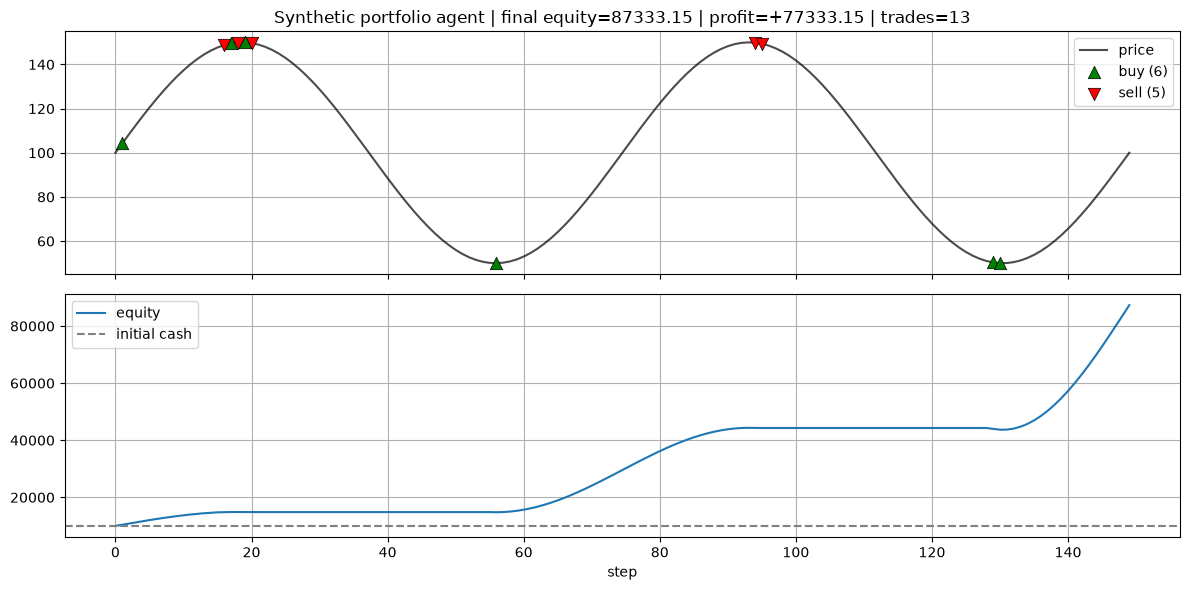

final equity: 87333.14972195645
trades      : 13


In [32]:
res = evaluate(agent, env, epsilon=0.0, title="Synthetic portfolio agent")
print("final equity:", res['final_equity'])
print("trades      :", res['trades'])

# Самостоятельное исследование 

Влияние гиперпараметров на прибыльность торгового робота

## 1. Цель работы

Провести систематическое исследование зависимости прибыльности DQN-агента от ключевых гиперпараметров.  
**Обязательное условие**: обучение проводится **только на train-среде**, оценка — **только на test-среде** (out-of-sample).  
Все выводы делаются по метрикам на тесте, train используется лишь для обучения и диагностики.  

**Центральный вопрос**: какие гиперпараметры критичны для out-of-sample прибыльности, а какие лишь улучшают fitting на train и провоцируют переобучение?

### Требования к выполнению:
- **Нормализация** (`price_mean`, `price_std`) должна считаться **только по train** и передаваться в test без пересчёта. Иначе — утечка будущего.
- **Тестовая среда никогда не используется для обучения**. Только финальная оценка.

## 2 Данные

Используйте:
- **Синтетику** (синусоида) — как контроль: там задача детерминированная, и гиперпараметры должны влиять предсказуемо.
- **Реальные данные MOEX** через `apimoex` (`SBER`, `GAZP`, `LKOH`) — как основной полигон.




Реальных торговых дней: 510


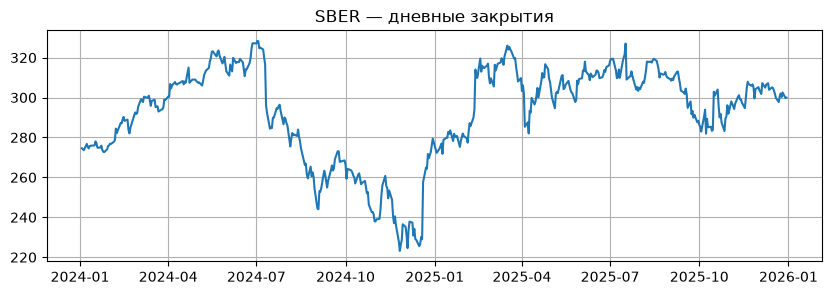

In [43]:
def load_moex_prices(ticker='SBER', board='TQBR',
                     start='2024-01-01', end='2026-01-01'):
    with requests.Session() as session:
        data = apimoex.get_board_history(
            session, security=ticker, board=board,
            start=start, end=end,
            columns=('TRADEDATE', 'CLOSE'),
        )
    df = pd.DataFrame(data)
    if df.empty:
        raise ValueError("Данные не получены — проверьте тикер/борд/даты")
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    df = df.sort_values('TRADEDATE').dropna(subset=['CLOSE']).reset_index(drop=True)
    return df['CLOSE'].values.astype(np.float32), df

real_prices, real_df = load_moex_prices('SBER')
print("Реальных торговых дней:", len(real_prices))

plt.figure(figsize=(10, 3))
plt.plot(real_df['TRADEDATE'], real_prices)
plt.title("SBER — дневные закрытия")
plt.grid(True)
plt.show()


## 3. Исследование влияния гиперпараметров

Каждый студент согласно своего номера по списку в файле с текущими оценками (на google drive) берёт **одну строку** из таблицы ниже. 
В таблице указаны только **имена параметров** — конкретное значение студент выбирает **сам** из предложенного диапазона, обосновывая выбор.

| # | Параметр A (обучение DQN) | Параметр B (исследование / среда) |
|---|---------------------------|-----------------------------------|
| 1 | `lr` | `eps_end` |
| 2 | `lr` | `decay` |
| 3 | `lr` | `n_episodes` |
| 4 | `lr` | `window` |
| 5 | `lr` | `commission` |
| 6 | `gamma` | `eps_end` |
| 7 | `gamma` | `decay` |
| 8 | `gamma` | `n_episodes` |
| 9 | `gamma` | `window` |
| 10 | `gamma` | `commission` |
| 11 | `batch_size` | `eps_end` |
| 12 | `batch_size` | `decay` |
| 13 | `batch_size` | `n_episodes` |
| 14 | `batch_size` | `window` |
| 15 | `batch_size` | `commission` |
| 16 | `target_update` | `eps_end` |
| 17 | `target_update` | `decay` |
| 18 | `target_update` | `n_episodes` |
| 19 | `target_update` | `window` |
| 20 | `target_update` | `commission` |
| 21 | `buffer_size` | `eps_end` |
| 22 | `buffer_size` | `decay` |
| 23 | `buffer_size` | `n_episodes` |
| 24 | `buffer_size` | `window` |
| 25 | `buffer_size` | `commission` |
| 26 | `hidden` | `eps_end` |
| 27 | `hidden` | `decay` |
| 28 | `hidden` | `n_episodes` |
| 29 | `hidden` | `window` |
| 30 | `hidden` | `commission` |

**Правило**: параметр A студент варьирует **внутри своей пары**, параметр B — тоже. Остальные гиперпараметры фиксируются на baseline, едином для всей группы (см. раздел 4).

| Параметр | Диапазон |
|----------|----------|
| `lr` | `1e-4 … 3e-3` (лог-шкала) |
| `gamma` | `0.90 … 0.99` |
| `batch_size` | `32 … 256` (степени двойки) |
| `target_update` | `50 … 500` |
| `buffer_size` | `1_000 … 50_000` |
| `hidden` | `32 … 256` |
| `eps_end` | `0.01 … 0.2` |
| `decay` | `0.99 … 1.0` |
| `n_episodes` | `200 … 1500` |
| `window` | `3 … 64` |
| `commission` | `0.0005 … 0.005` |

Baseline (общий для всех). Эти значения фиксированы и **не меняются** у всех студентов:

```py
BASELINE = {
    # группа A
    'lr': 1e-3,
    'gamma': 0.97,
    'batch_size': 64,
    'target_update': 200,
    'buffer_size': 10_000,
    'hidden': 64,
    # группа B
    'eps_end': 0.05,
    'decay': 0.995,
    'n_episodes': 800,
    'window': 5,
    'commission': 0.001,
    # среда
    'initial_cash': 10_000.0,
    'hold_penalty': 0.0,
}
```
Студент меняет **только два** параметра — A и B из своей пары. Все остальные остаются baseline.

**Диапазоны для выбора значений** (студент берёт минимум **3 значения** на каждый параметр, чтобы можно было построить кривую):

**Минимум 3 значения × 3 сида = 9 запусков** на студента. Рекомендуется 4 значения → 12 запусков.

## 4. Методика эксперимента

### 4.1 Единый протокол

Для каждого значения гиперпараметра:

1. Зафиксировать сиды: `random.seed(42)`, `np.random.seed(42)`, `torch.manual_seed(42)`.
2. Создать **новые** `env_train` и `env_test` (среда имеет внутреннее состояние — переиспользовать нельзя).
3. Обучить агента **только на `env_train`** на `n_episodes` эпизодов.
4. Оценить агента **только на `env_test`** с `epsilon=0.0`.
5. Сохранить метрики test.
6. Повторить **минимум 3 раза с разными сидами** (seeds `42, 43, 44`), усреднить результаты.

**Зачем несколько сидов**: RL очень чувствителен к инициализации и порядку сэмплирования. Один запуск — не результат.



In [48]:
### 4.2 Шаблон эксперимента
def run_experiment(param_name, param_value,
                   real_prices, n_episodes=800, seeds=(42, 43, 44)):
    results = []
    split = int(len(real_prices) * 0.7)
    train_prices = real_prices[:split]
    test_prices  = real_prices[split:]
    for seed in seeds:
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

        env_train = PortfolioEnv(train_prices, window=32, initial_cash=10_000.0,
                                 commission=0.001, hold_penalty=0.0)
        env_test  = PortfolioEnv(test_prices,  window=32, initial_cash=10_000.0,
                                 commission=0.001, hold_penalty=0.0)

        # применяем исследуемый гиперпараметр
        kwargs = {param_name: param_value}
        agent = DQNAgent(env_train.state_dim, env_train.n_actions, **kwargs)
        agent, hist = train(env_train, agent=agent, n_episodes=n_episodes,
                            verbose_every=100)  

        res_test = evaluate(agent, env_test, epsilon=0.0, render=True)
        metrics = {
            'seed': seed,
            'param': param_name,
            'value': param_value,
            'train_equity': hist['equity'][-1],
            'test_equity': res_test['final_equity'],
            'test_profit': res_test['profit'],
            'test_trades': res_test['trades'],
        }
        results.append(metrics)
    return pd.DataFrame(results)

[ 100/800] reward= 287.373 loss= 1.056 eps=0.609 trades=193 equity=  17521.22 profit=  7521.22
[ 200/800] reward= 788.165 loss= 0.806 eps=0.369 trades=169 equity=  30628.10 profit= 20628.10
[ 300/800] reward=1244.718 loss= 0.747 eps=0.223 trades=157 equity=  42577.13 profit= 32577.13
[ 400/800] reward=1249.821 loss= 0.603 eps=0.135 trades=159 equity=  42710.69 profit= 32710.69
[ 500/800] reward=1367.064 loss= 0.564 eps=0.082 trades=136 equity=  45779.22 profit= 35779.22
[ 600/800] reward=1468.782 loss= 0.524 eps=0.050 trades=148 equity=  48441.41 profit= 38441.41
[ 700/800] reward=1622.008 loss= 0.392 eps=0.050 trades=154 equity=  52451.68 profit= 42451.68
[ 800/800] reward=1489.071 loss= 0.416 eps=0.050 trades=143 equity=  48972.41 profit= 38972.41


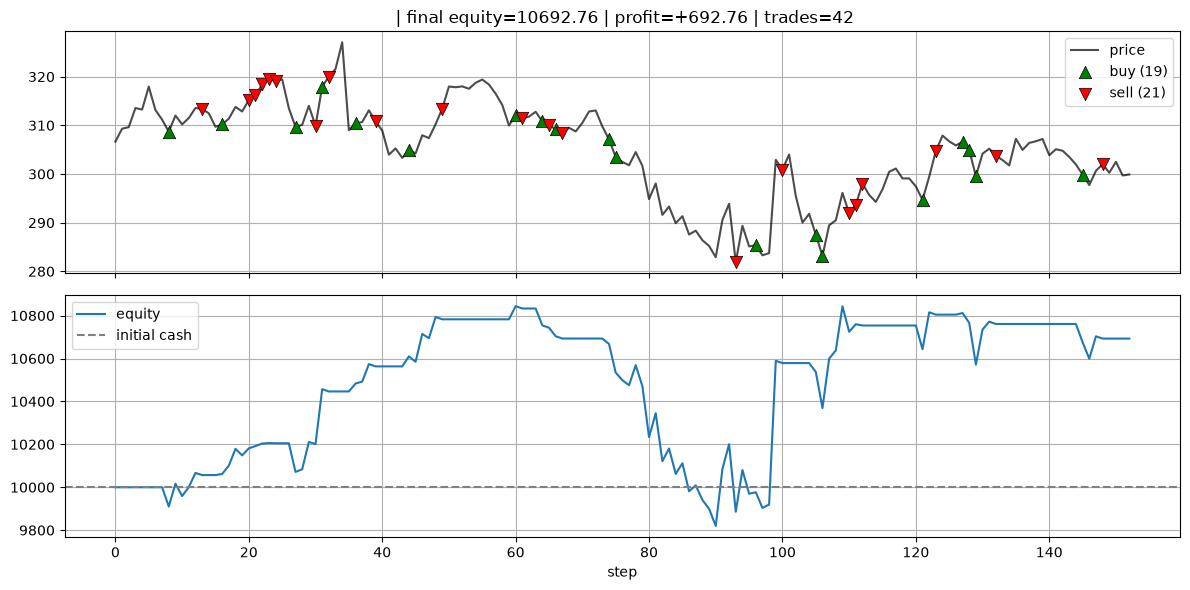

[ 100/800] reward= 383.092 loss= 0.968 eps=0.609 trades=187 equity=  20026.39 profit= 10026.39
[ 200/800] reward= 855.363 loss= 0.896 eps=0.369 trades=178 equity=  32386.81 profit= 22386.81
[ 300/800] reward=1073.240 loss= 0.753 eps=0.223 trades=156 equity=  38089.16 profit= 28089.16
[ 400/800] reward=1351.071 loss= 0.714 eps=0.135 trades=136 equity=  45360.64 profit= 35360.64
[ 500/800] reward=1599.828 loss= 0.591 eps=0.082 trades=153 equity=  51871.19 profit= 41871.19
[ 600/800] reward=1654.266 loss= 0.504 eps=0.050 trades=132 equity=  53295.96 profit= 43295.96
[ 700/800] reward=1625.104 loss= 0.491 eps=0.050 trades=140 equity=  52532.71 profit= 42532.71
[ 800/800] reward=1624.716 loss= 0.479 eps=0.050 trades=145 equity=  52522.57 profit= 42522.57


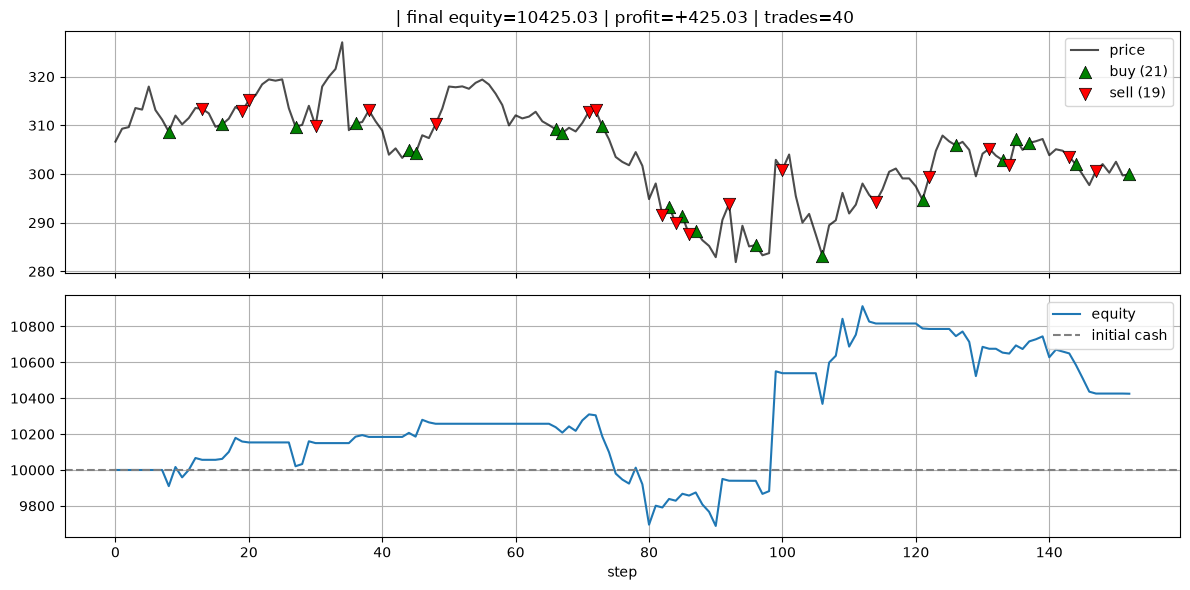

[ 100/800] reward= 415.433 loss= 1.087 eps=0.609 trades=194 equity=  20872.84 profit= 10872.84
[ 200/800] reward= 486.086 loss= 0.966 eps=0.369 trades=198 equity=  22722.00 profit= 12722.00
[ 300/800] reward=1044.034 loss= 0.836 eps=0.223 trades=168 equity=  37324.77 profit= 27324.77
[ 400/800] reward=1184.104 loss= 0.681 eps=0.135 trades=167 equity=  40990.72 profit= 30990.72
[ 500/800] reward=1284.411 loss= 0.583 eps=0.082 trades=134 equity=  43616.00 profit= 33616.00
[ 600/800] reward=1481.165 loss= 0.560 eps=0.050 trades=151 equity=  48765.51 profit= 38765.51
[ 700/800] reward=1594.616 loss= 0.533 eps=0.050 trades=143 equity=  51734.78 profit= 41734.78
[ 800/800] reward=1608.443 loss= 0.444 eps=0.050 trades=155 equity=  52096.66 profit= 42096.66


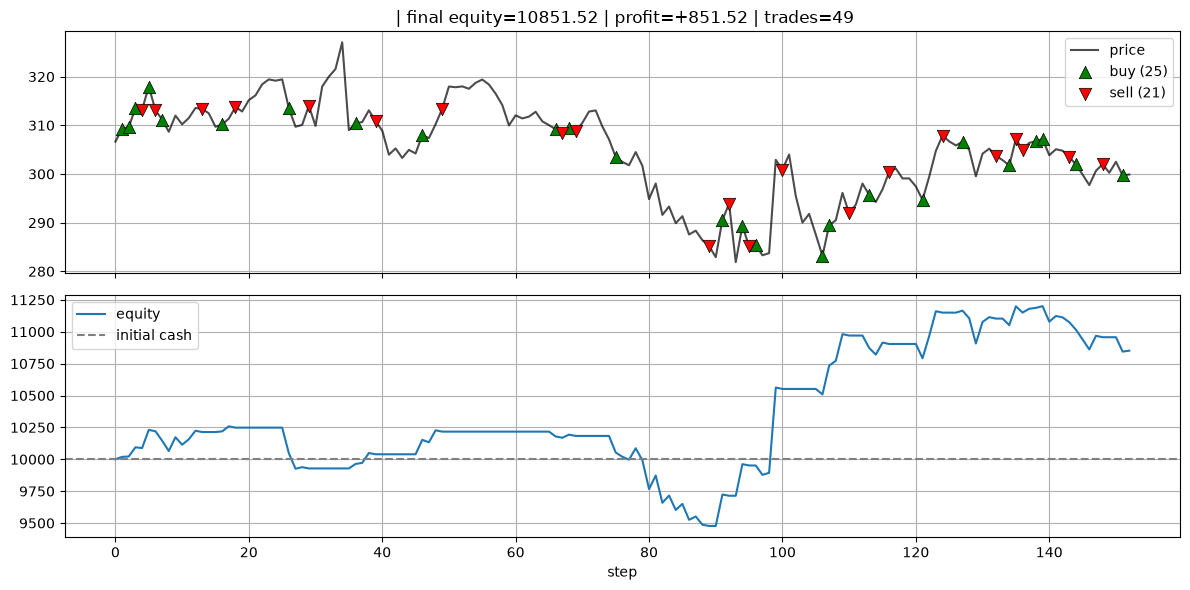

In [49]:
results = run_experiment('lr', 1e-3, real_prices)

In [50]:
print(results)

   seed param  value  train_equity   test_equity  test_profit  test_trades
0    42    lr  0.001  48972.411698  10692.764015   692.764015           42
1    43    lr  0.001  52522.566506  10425.027652   425.027652           40
2    44    lr  0.001  52096.660918  10851.516997   851.516997           49



## 5. Обязательные метрики

Для каждой конфигурации считайте:

| Метрика | Формула / смысл |
|---------|-----------------|
| **train_equity** | финальный equity на train |
| **test_equity** | финальный equity на test |
| **test_profit** | `test_equity − initial_cash` |
| **test_return** | `test_profit / initial_cash` |
| **test_trades** | число сделок на test |
| **test_sharpe** | `mean(returns) / std(returns) · √252` |
| **test_max_dd** | максимальная просадка |
| **buy_hold_test** | прибыль Buy & Hold на test |
| **random_test** | прибыль случайного агента (усреднить 20 запусков) |

**Ключевое требование**: сравнивать не только между собой, но и с бейзлайнами. Если DQN не обгоняет Buy & Hold — гиперпараметр не даёт практической ценности, даже если test_profit положительный.

---

## 6. Анализ результатов

### 6.1 Таблицы

Для каждой группы постройте сводную таблицу (усреднённую по сидам):

```
| param_value | train_equity | test_equity | test_profit | test_sharpe | test_max_dd | trades |
|-------------|--------------|-------------|-------------|-------------|-------------|--------|
| 1e-4        | ...          | ...         | ...         | ...         | ...         | ...    |
| 3e-4        | ...          | ...         | ...         | ...         | ...         | ...    |
| 1e-3        | ...          | ...         | ...         | ...         | ...         | ...    |
| 3e-3        | ...          | ...         | ...         | ...         | ...         | ...    |
```

### 6.2 Графики

Для каждой группы — **два графика рядом**:

1. `train_equity` и `test_equity` vs значение гиперпараметра.
2. `test_sharpe` (или `test_profit`) vs значение гиперпараметра, **с горизонтальной линией Buy & Hold**.

Ключевой визуальный паттерн: **расхождение train и test кривых** = переобучение. Чем больше разрыв, тем хуже обобщение.

### 6.3 Обязательные вопросы

В отчёте ответьте:

1. **Какой гиперпараметр сильнее влияет на test_profit?** Подтвердите цифрами.
2. **Где начинается переобучение?** Найдите значения параметров, при которых `train_equity` продолжает расти, а `test_equity` падает.
3. **Устойчивость к сидам**: какой параметр даёт наибольший разброс `test_profit` между сидами? Это признак нестабильности — такие конфигурации опасны в реальной торговле.
4. **Комиссия**: как меняется число сделок и прибыль при росте `commission`? Есть ли точка, после которой DQN проигрывает Buy & Hold?
5. **Окно `window`**: улучшает ли большее окно test-метрики, или агент начинает переобучаться на шум?
6. **`gamma`**: короткий горизонт (0.90) или длинный (0.99) лучше для out-of-sample? Почему?
7. **`hold_penalty`**: снижает ли штраф за удержание частоту сделок и улучшает ли Sharpe?


## 7. Структура отчёта

1. **Постановка задачи** и описание train/test-разделения.
2. **Baseline**: DQN с параметрами по умолчанию, Buy & Hold, Random — таблица метрик на test.
3. **Результаты по группам A–D**: по одной таблице и одному графику на группу.
4. **Сводная таблица лучших конфигураций** по test_profit и test_sharpe.
5. **Анализ**: ответы на вопросы из раздела 6.3.
6. **Ограничения**: почему RL на финансах может не работать даже при хороших гиперпараметрах (низкий SNR, нестационарность, режимные сдвиги).
7. **Выводы**: какие гиперпараметры рекомендованы для реальной торговли, какие — только для fitting на train.
